In [1]:
from snudd.nsi import earth_matter as em 

In [2]:
from snudd.nsi import oscillation as osc 

In [3]:
from snudd.models import GeneralNSI

In [4]:
import numpy as np

In [5]:
SM_matrix = np.array([[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]])

eta = 0
phi = 0

sm_model = GeneralNSI(SM_matrix, eta, phi)

In [12]:
def my_profile(r):  # r in [0,1]
    # e.g., 2-zone model + tiny crust tweak
    Ye = 0.47 if r < 0.55 else 0.495
    rho = (13.0 - 8.0*r*r) if r < 0.55 else (5.5 - 3.0*(r-0.55))  # g/cm^3
    return Ye * rho

funcmodel = em.CallableEarth(f=my_profile)
EProb = em.EarthProbEvolve(osc_params=osc.osc_params_best, model=sm_model, earthmodel=funcmodel)

In [13]:
EProb.S_matrix(Enu_GeV=10.0, ceta=0.5)

array([[ 0.68782955+0.5250804j ,  0.37596294-0.01587803j,
         0.3303545 -0.02113625j],
       [ 0.37595142-0.01653217j,  0.0746467 +0.30309717j,
        -0.80544204+0.33497807j],
       [ 0.33029765-0.02172011j, -0.80544951+0.33497884j,
         0.29293045+0.20895865j]])

In [14]:
xr_km = [0., 1221.5, 3480.0, 5701.0, 5771.0, 5971.0, 6151.0,
               6346.6, 6356.0, 6368.0, 6371.0, 6371.0 + 15.0]  # your boundaries
coeffs = [
    (13.0885, 0.0, -8.8381, 0.0),   # layer 1: a,b,c,d in r = R/RE
    (12.5815, -1.2638, -3.6426, -5.528),  # layer 2
    (7.9565,  -6.4761,  5.5283,  -3.0807),  # ...
    (5.3197,  -1.4836,  0.0,  0.0),
    (11.2494,  -8.0298,  0.0,  0.0),
    (7.1089,  -3.8045,  0.0,  0.0),
    (2.6910,   0.6924,  0.0,  0.0),
    (2.9,      0.0,  0.0,  0.0),
    (2.6,    0.0,  0.0,  0.0),
    (1.02,    0.0,  0.0,  0.0),
    (0.000,    0.0,  0.0,  0.0),
]
PREMmodel = em.LayeredPolyEarth(xr_km=xr_km, coeffs=coeffs,
                         Ye_core=0.466, Ye_mantle=0.494)
PREMprob = em.EarthProbEvolve(osc_params=osc.osc_params_best, model=sm_model, earthmodel=PREMmodel, Nst=50, Nav=50 )

In [15]:
PREMprob.S_matrix(Enu_GeV=10.0, ceta=0.5)

array([[ 0.30660608+0.79554545j,  0.38022408+0.09369932j,
         0.33844917+0.07212761j],
       [ 0.38246773+0.08439559j,  0.08565475+0.30395975j,
        -0.79663542+0.33502173j],
       [ 0.34004164+0.0637781j , -0.79667024+0.33501992j,
         0.29985969+0.20848593j]])

In [16]:
def Probs_diag(Enu_GeV: float, ceta: float, probevolve) -> np.ndarray:
    S = probevolve.S_matrix(Enu_GeV, ceta)
    amps = S[:, 0]                 # first column → νe→{e,μ,τ}
    return np.abs(amps)**2         # array([Pee, Peμ, Peτ])


In [17]:
from joblib import Parallel, delayed

def Probs_diag_parallel(Enu_array, ceta, propagator, n_jobs=-1):
    results = Parallel(n_jobs=n_jobs)(
        delayed(Probs_diag)(E, ceta, propagator) for E in Enu_array
    )
    probs = np.vstack(results).T
    return probs

In [18]:
Enuspace = np.geomspace(1e-6,2e1, 400)

Pee, Pemu, Petau = Probs_diag_parallel(Enuspace, 0.025, PREMprob, n_jobs=4)

In [19]:
import matplotlib.pyplot as plt


Text(0.5, 1.0, '$\\cos(\\eta)=0.025$')

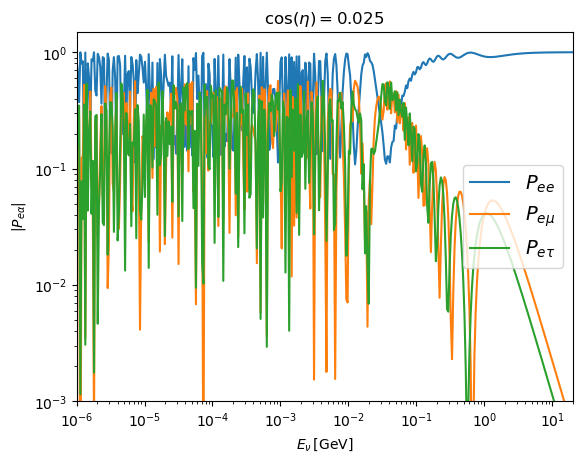

In [20]:

plt.loglog(Enuspace, Pee, label=r'$P_{ee}$')
plt.loglog(Enuspace, Pemu, label=r'$P_{e\mu}$')
plt.loglog(Enuspace, Petau, label=r'$P_{e\tau}$')

plt.ylim(ymin=1e-3, ymax=1.5)
plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.xlabel(r'$E_{\nu}\,\left[{\rm GeV}\right]$')
plt.ylabel(r'$\vert P_{e \alpha}\vert$')
plt.legend(fontsize=14, loc='right')
plt.title(r'$\cos(\eta)=0.025$')

In [21]:
def evolve_through_earth(rho_solar_stack, enus_GeV, ceta, probevolve):
    """
    rho_solar_stack: (N,3,3) complex array  [your solar density matrices at Earth surface]
    enus_GeV       : (N,) energies
    ceta           : scalar cos(nadir)
    propagator     : an object with S_matrix(E, ceta) -> (3,3) complex

    Returns:
      rho_earth_stack : (N,3,3) complex
    """
    # 1) build S(E) for all energies
    S_list = [probevolve.S_matrix(E, ceta) for E in enus_GeV]
    S = np.stack(S_list, axis=0)                    # (N,3,3)
    Sdag = np.swapaxes(S.conj(), -1, -2)            # (N,3,3)

    # 2) batch multiply: S ρ S†   (use matmul with batch dims)
    tmp = np.matmul(S, rho_solar_stack)             # (N,3,3)
    rho_earth = np.matmul(tmp, Sdag)                # (N,3,3)


    return rho_earth 

In [22]:
import snudd.nsi.nsi_probabilities as probs

In [23]:
density_sm = probs.DensityMatrixCalculator(sm_model).density(Enuspace, '8B')

In [24]:
rho_earth = evolve_through_earth(density_sm, Enuspace, ceta=np.cos(np.pi/2- np.pi*25.0/180) , probevolve=PREMprob)


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

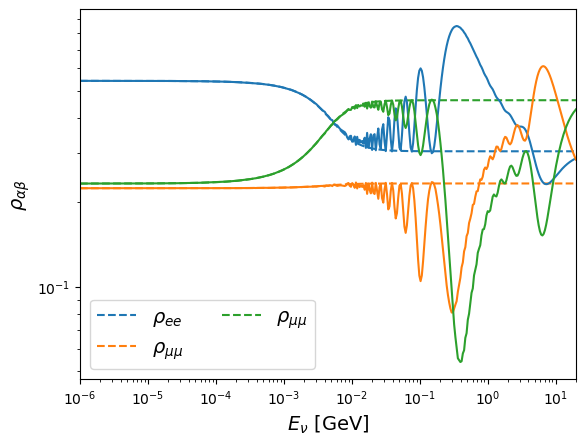

In [25]:
plt.loglog(Enuspace,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_earth[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_earth[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_earth[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

#plt.loglog(Enuspace, Pee*, label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

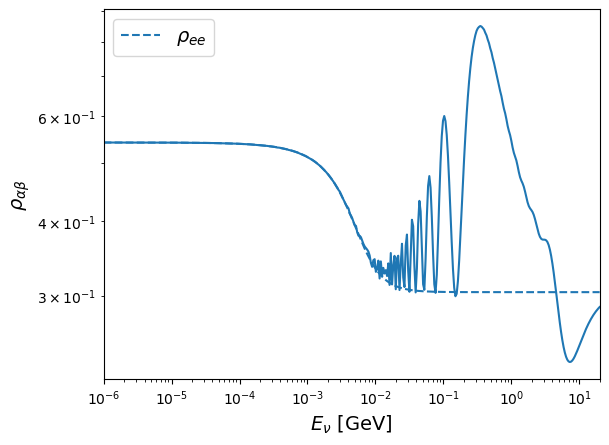

In [26]:
plt.loglog(Enuspace,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
            
plt.loglog(Enuspace,abs(rho_earth[:, 0,0]),  color="tab:blue" )


# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace, Pee*abs(density_sm[:, 0,0]), label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

In [27]:
from snudd.nsi.oscillation import OscillationParameters

In [28]:
delta_m12 = 7.42e-5 *( 1e-9) ** 2 # GeV^2
delta_m31 = 2.517e-3 * (1e-9) ** 2  # GeV^2
theta_12 = np.arcsin(np.sqrt(0.304))
theta_13 = np.arcsin(np.sqrt(0.02219)) # NORMAL ORDERING
theta_23 = np.arcsin(np.sqrt(0.573))
delta_cp = 4.71238898038469  # CP angle

params1 = OscillationParameters(delta_m12, delta_m31,
                                        theta_12,
                                        theta_13,
                                        theta_23,
                                        delta_cp)

In [29]:
rho_sun2 = probs.DensityMatrixCalculator(sm_model, osc_params=params1).density(Enuspace, '8B')

In [30]:
PREMprob2 = em.EarthProbEvolve(osc_params=params1, model=sm_model, earthmodel=PREMmodel)

In [31]:
rho_earth2 = evolve_through_earth(rho_sun2, Enuspace, ceta=0.025, probevolve=PREMprob2)


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

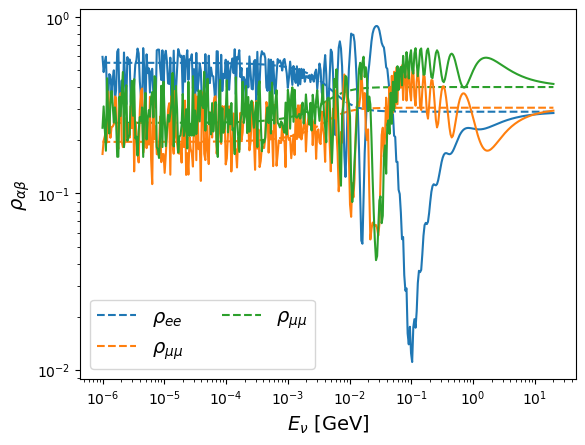

In [32]:
plt.loglog(Enuspace,abs(rho_sun2[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(rho_sun2[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(rho_sun2[:, 2,2]),  label=r'$\rho_{\mu\mu}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_earth2[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_earth2[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_earth2[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

In [33]:
Pee2, Pemu2, Petau2 = Probs_diag_parallel(Enuspace, 0.025, PREMprob2, n_jobs=4)

Text(0.5, 1.0, '$\\cos(\\eta)=0.025$')

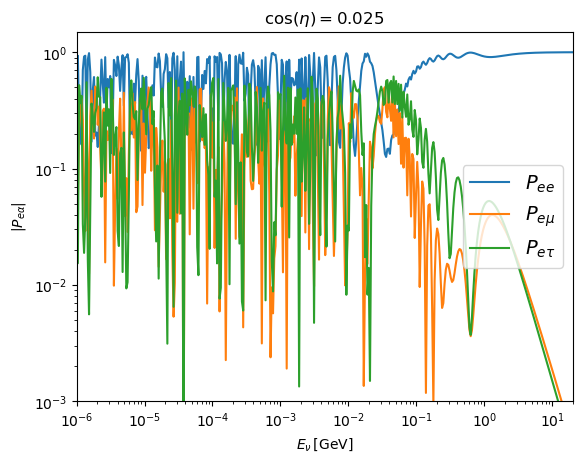

In [34]:

plt.loglog(Enuspace, Pee2, label=r'$P_{ee}$')
plt.loglog(Enuspace, Pemu2, label=r'$P_{e\mu}$')
plt.loglog(Enuspace, Petau2, label=r'$P_{e\tau}$')

plt.ylim(ymin=1e-3, ymax=1.5)
plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.xlabel(r'$E_{\nu}\,\left[{\rm GeV}\right]$')
plt.ylabel(r'$\vert P_{e \alpha}\vert$')
plt.legend(fontsize=14, loc='right')
plt.title(r'$\cos(\eta)=0.025$')

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

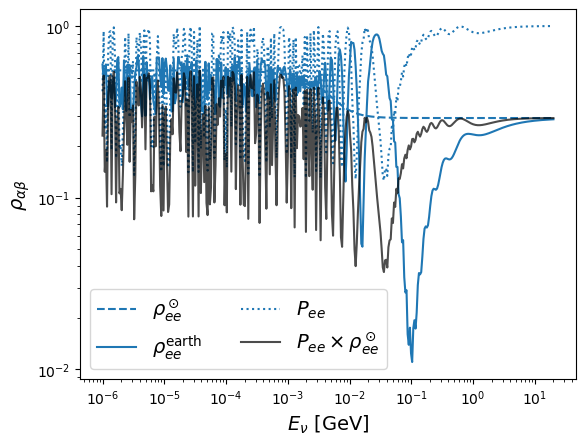

In [35]:
plt.loglog(Enuspace,abs(rho_sun2[:, 0,0]),  label=r'$\rho_{ee}^\odot$', 
            color="tab:blue", ls='--' )

plt.loglog(Enuspace,abs(rho_earth2[:, 0,0]),  label=r'$\rho_{ee}^{\rm earth}$',  color="tab:blue" )


plt.loglog(Enuspace, Pee2, label=r'$P_{ee}$', ls=':', color="tab:blue" )

plt.loglog(Enuspace, abs(Pee2*rho_sun2[:, 0,0]), label=r'$P_{ee}\times\rho_{ee}^\odot$', ls='-', color="k", alpha=0.7 )


# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

Fewer slabs in the numerical calculation 

In [ ]:
PREMprop3 = em.EarthProbEvolve(osc_params=params1, model=sm_model, earthmodel=PREMmodel,
                               Nst=50, Nav=50)

In [40]:
rho_earth3 = evolve_through_earth(rho_sun2, Enuspace, ceta=0.025, probevolve=PREMprop3)



(1e-06, 20.0)

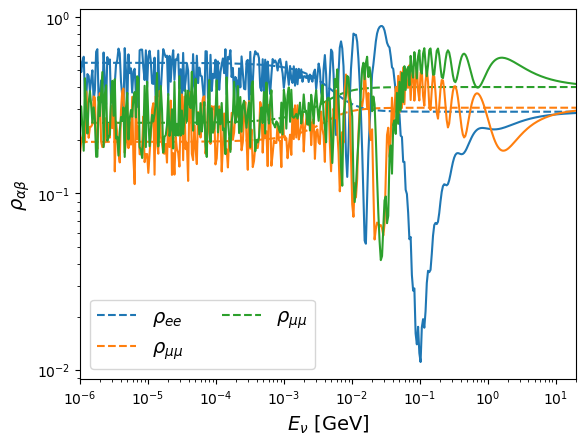

In [41]:
plt.loglog(Enuspace,abs(rho_sun2[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(rho_sun2[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(rho_sun2[:, 2,2]),  label=r'$\rho_{\mu\mu}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_earth3[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_earth3[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_earth3[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)
plt.xlim(xmin=1e-6, xmax=2.0e1)


In [42]:
delta_m12 = 7.42e-5 *( 1e-9) ** 2 # GeV^2
delta_m31 = 2.517e-3 * (1e-9) ** 2  # GeV^2
theta_12 = np.arcsin(np.sqrt(0.304))
theta_13 = np.arcsin(np.sqrt(0.02219)) # NORMAL ORDERING
theta_23 = np.arcsin(np.sqrt(0.573))
delta_cp0 = 0.0

params_cp0 = OscillationParameters(delta_m12, delta_m31,
                                        theta_12,
                                        theta_13,
                                        theta_23,
                                        delta_cp0)

In [43]:
rho_suncp0 = probs.DensityMatrixCalculator(sm_model, osc_params=params_cp0).density(Enuspace, '8B')

In [45]:
PREMpropcp0 = em.EarthProbEvolve(osc_params=params_cp0, model=sm_model, earthmodel=PREMmodel,
                               Nst=50, Nav=50)


In [46]:
rho_earth_cp0 = evolve_through_earth(rho_suncp0, Enuspace, ceta=0.025, probevolve=PREMpropcp0)


(1e-06, 20.0)

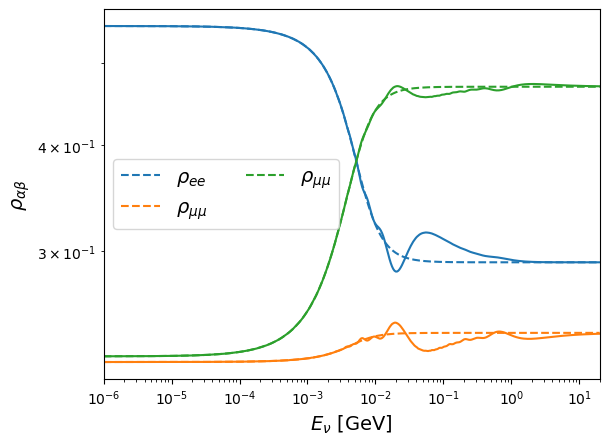

In [47]:
plt.loglog(Enuspace,abs(rho_suncp0[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(rho_suncp0[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(rho_suncp0[:, 2,2]),  label=r'$\rho_{\mu\mu}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_earth_cp0[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_earth_cp0[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_earth_cp0[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)
plt.xlim(xmin=1e-6, xmax=2.0e1)